# Plant Disease Prediction 

## Importing Libraries

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## Test Set Image Processing

In [3]:
base_data_directory = '/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)'

In [4]:
import os
valid_directory = os.path.join(base_data_directory, 'valid')
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_directory,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)
class_name = validation_set.class_names
print(class_name)

Found 17572 files belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Tw

2025-06-10 15:24:00.063922: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Loading Model

In [5]:
model_path = '/kaggle/input/plant-disease-cnn-train/trained_plant_disease_model.keras' # <--- THIS IS THE LINE TO CHANGE
cnn = tf.keras.models.load_model(model_path)

## Visualising and Performing Prediction on Single image

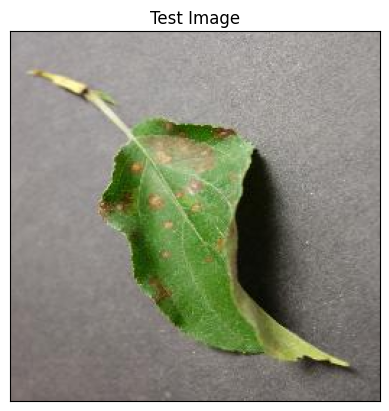

In [6]:
#Test Image Visualization
import cv2
image_path = '/kaggle/input/new-plant-diseases-dataset/test/test/AppleCedarRust3.JPG'

# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB

# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [7]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

I0000 00:00:1749569062.619246     224 service.cc:148] XLA service 0x7d27c400a600 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749569062.619294     224 service.cc:156]   StreamExecutor device (0): Host, Default Version


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step


I0000 00:00:1749569062.860708     224 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [8]:
print(predictions)

[[1.5781856e-06 1.5710998e-07 6.3338584e-01 3.1892023e-06 2.1781432e-06
  3.5316894e-05 2.2798864e-07 3.2117764e-06 1.7790348e-09 7.5081786e-08
  1.1032030e-08 3.2547195e-04 3.3947267e-03 2.9852604e-06 2.9574403e-09
  6.8937607e-07 2.4402460e-01 8.8734691e-05 1.8913664e-04 6.2091494e-06
  4.2129142e-07 1.3090987e-07 5.6989009e-08 8.0590726e-06 4.1530072e-08
  4.1725713e-08 2.0288186e-04 4.5787387e-09 2.4477430e-02 5.9213672e-02
  9.3681581e-04 3.3311166e-02 2.7258371e-04 1.8285984e-06 1.0610923e-05
  7.0406779e-05 2.5931358e-05 3.6180397e-06]]


In [9]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

2


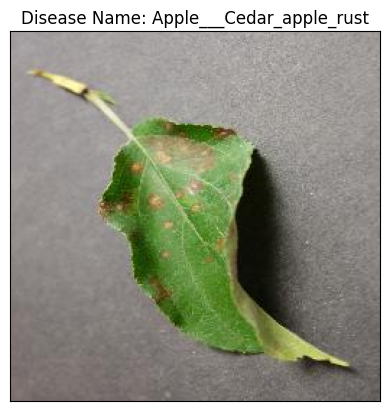

In [10]:
# Displaying the disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()